# Импорты библиотек

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator
from IPython.display import display
import scipy.stats as stats
import seaborn as sns
import scikit_posthocs as sp
from pathlib import Path

# Чтение данных

In [2]:
# Для отображения чисел не в экспоненциальном виде, а обрезанными до двух знаков после запятой
pd.options.display.float_format = '{:.2f}'.format

In [3]:
project_dir = Path.cwd().parent
data_path = project_dir / 'data' / 'marketplace.csv'
df = pd.read_csv(data_path)
df.head()

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.00,138.78,0.00
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       25335 non-null  object 
 1   platform_num  25335 non-null  int64  
 2   first_login   25335 non-null  object 
 3   reg_dt        25331 non-null  object 
 4   browser       25335 non-null  object 
 5   first_buy     24361 non-null  object 
 6   target        25335 non-null  float64
 7   total_buy     25335 non-null  float64
 8   total_return  25335 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.7+ MB


In [5]:
#Приведение дат к datetime
date_cols = ["first_login", "reg_dt", "first_buy"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       25335 non-null  object        
 1   platform_num  25335 non-null  int64         
 2   first_login   25335 non-null  datetime64[ns]
 3   reg_dt        25331 non-null  datetime64[ns]
 4   browser       25335 non-null  object        
 5   first_buy     24361 non-null  datetime64[ns]
 6   target        25335 non-null  float64       
 7   total_buy     25335 non-null  float64       
 8   total_return  25335 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.7+ MB


In [6]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
platform_num,25335.00,6.47,17.02,1.00,2.00,3.00,6.00,674.00
target,25335.00,0.00,0.25,-3.43,0.00,0.00,0.00,0.30
total_buy,25335.00,898.55,6815.55,0.00,19.36,52.72,203.53,490447.99
total_return,25335.00,334.08,2882.91,0.00,0.00,0.00,0.00,207893.84


In [7]:
total_rows   = len(df)
unique_users = df["user_id"].nunique()
extra_rows   = total_rows - unique_users

dup_counts = (
    df["user_id"]
    .value_counts()
    .loc[lambda s: s > 1]
)

num_users_with_dups   = dup_counts.size
share_users_with_dups = (num_users_with_dups / unique_users * 100) if unique_users > 0 else 0.0
share_rows_with_dups  = (extra_rows / total_rows * 100) if total_rows > 0 else 0.0

print(f"Всего строк в датасете:                    {total_rows}")
print(f"Уникальных пользователей (user_id):        {unique_users}")
print(f"Лишних строк из-за дублей:                 {extra_rows} ({share_rows_with_dups:.3f}%)")
print(f"Пользователей, представленных >1 строкой:  {num_users_with_dups} ({share_users_with_dups:.3f}%)")

if num_users_with_dups > 0:
    print("\nСписок user_id с дублями и числом строк по каждому:")

    dup_df = (
        dup_counts
        .rename_axis("user_id")           
        .reset_index(name="row_count")
    )

    display(dup_df)
else:
    print("\nДублей по user_id не обнаружено.")

Всего строк в датасете:                    25335
Уникальных пользователей (user_id):        25331
Лишних строк из-за дублей:                 4 (0.016%)
Пользователей, представленных >1 строкой:  4 (0.016%)

Список user_id с дублями и числом строк по каждому:


,user_id,row_count
0,user_000072,2
1,user_000383,2
2,user_006319,2
3,user_019702,2


# Чистка данных

**Обнаружение дублей по пользователям**

На этапе проверки качества данных был проведён анализ уникальности идентификаторов пользователей (user_id).
Всего в датасете содержится 25 335 строк и 25 331 уникальный user_id, то есть 4 пользователя представлены двумя строками каждый.
Доля таких пользователей от всей клиентской базы составляет около 0,016 %, доля «лишних» строк — также порядка 0,016 %.
Формально влияние дублей на агрегированные показатели невелико, однако для корректного анализа на уровне пользователя важно, чтобы каждому user_id соответствовала ровно одна запись.

Поэтому было принято решение привести датасет к формату «одна строка = один пользователь».

**Алгоритм устранения дублей**

Так как данные представляют собой снимок состояния пользователей на определённые даты, для каждого user_id мы оставляем наиболее «свежий» срез. В качестве приближения к времени среза используем дату первого входа в личный кабинет (first_login):

1. Сортируем датафрейм по user_id и first_login по возрастанию.
В результате для каждого пользователя строки упорядочены от более ранних логинов к более поздним.

2. Удаляем дубликаты user_id, оставляя последнюю строку для каждого пользователя (keep="last"), то есть запись с максимально поздним first_login.

3. Сбрасываем индекс и дополнительно проверяем, что user_id стал уникален.

Таким образом, мы получаем очищенный датасет, в котором каждая строка соответствует одному пользователю в его последнем доступном состоянии.

In [8]:
rows_before = df.shape[0]

df_sorted = df.sort_values(["user_id", "first_login"])

df_clean = (
    df_sorted
    .drop_duplicates(subset="user_id", keep="last")
    .reset_index(drop=True)
)

df = df_clean.copy()
rows_after = df.shape[0]

print(f"Строк до очистки:                     {rows_before}")
print(f"Строк после очистки:                  {rows_after}")
print(f"Удалено строк:                        {rows_before - rows_after}")
print(f"user_id уникальны после очистки:      {df_clean['user_id'].is_unique}")

Строк до очистки:                     25335
Строк после очистки:                  25331
Удалено строк:                        4
user_id уникальны после очистки:      True


# Гипотезы

## Гипотеза 2

Пользователи, у которых уже были возвраты до момента среза (выше исторический коэффициент возвратов total_return / total_buy), с большей вероятностью совершают возвраты в течение следующего месяца (имеют положительный target > 0).

*Для этой гипотезы было принято исключить строки с target < 0 как аномальные значения и сравнивать только пользователей с target = 0 и target > 0.*

**Стратегия проверки гипотезы**

1. Отфильтровать данные: оставить только пользователей с target ≥ 0.

2. Для каждого пользователя посчитать исторический коэффициент возвратов:

    - если total_buy = 0 → выделить отдельную группу «нет покупок»;

    - если total_buy > 0 и total_return = 0 → группа «0% возвратов»;

    - если total_buy > 0 и total_return > 0 → hist_return_rate = total_return / total_buy.

3. Разбить пользователей по корзинам исторического коэффициента возвратов:

    - нет покупок,

    - 0% возвратов,

    - 0–10%,

    - 10–50%,

    - 50–100%,

    - 100–500%,

    - больше 500%.

4. Для каждой корзины посчитать:

    - количество пользователей;

    - долю пользователей с возвратами в будущем (target > 0);

    - среднее значение target в следующем месяце.

5. Визуализировать:

    - таблицу с метриками по корзинам;

    - столбчатую диаграмму: доля пользователей с target > 0 по корзинам.

=== Гипотеза 2. Исторические возвраты и будущие возвраты ===

--- Описательные статистики hist_return_rate (там, где он посчитан) ---


,count,mean,std,min,25%,50%,75%,max
hist_return_rate,5247.00,11.08,529.79,0.00,0.35,0.63,1.45,38227.85



--- Распределение пользователей по корзинам исторических возвратов: ---


,Корзина по историческому коэффициенту возвратов,Количество пользователей
0,нет покупок,966
1,0% возвратов,19118
2,0–10%,170
3,10–50%,1885
4,50–100%,1365
5,100–500%,1466
6,>500%,361



--- Метрики по корзинам исторических возвратов: ---


,Корзина по историческому коэффициенту возвратов,Количество пользователей,"Доля пользователей с возвратами, %",Среднее значение target
0,нет покупок,966,4.14,-0.01
1,0% возвратов,19118,5.80,0.01
2,0–10%,170,17.06,0.01
3,10–50%,1885,24.14,0.01
4,50–100%,1365,16.12,-0.03
5,100–500%,1466,6.75,-0.03
6,>500%,361,4.16,-0.04


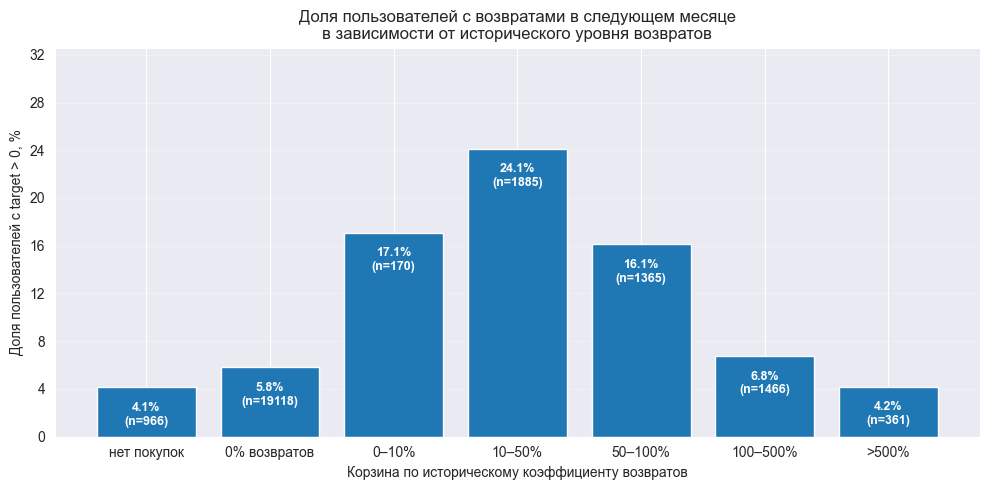

In [9]:
print("=== Гипотеза 2. Исторические возвраты и будущие возвраты ===")

# 1. Фильтруем аномалии: оставляем только target >= 0
#df_h2 = df[df["target"] >= 0].copy()
#print(f"Строк после исключения target < 0: {df_h2.shape[0]}")

# 2. Строим исторический коэффициент возвратов
mask_no_buys     = df["total_buy"] == 0
mask_zero_ret    = (df["total_buy"] > 0) & (df["total_return"] == 0)
mask_nonzero_ret = (df["total_buy"] > 0) & (df["total_return"] > 0)

df["hist_return_rate"] = np.nan
df.loc[mask_nonzero_ret, "hist_return_rate"] = (
    df.loc[mask_nonzero_ret, "total_return"] /
    df.loc[mask_nonzero_ret, "total_buy"]
)

print("\n--- Описательные статистики hist_return_rate (там, где он посчитан) ---")
display(df["hist_return_rate"].describe().to_frame().T)

# 3. Формируем корзины по историческим возвратам

# порядок корзин, который будем использовать везде
bucket_order = [
    "нет покупок",
    "0% возвратов",
    "0–10%",
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]

df["hist_return_bucket"] = None

df.loc[mask_no_buys,  "hist_return_bucket"] = "нет покупок"
df.loc[mask_zero_ret, "hist_return_bucket"] = "0% возвратов"

bins   = [0, 0.1, 0.5, 1, 5, np.inf]
labels = ["0–10%", "10–50%", "50–100%", "100–500%", ">500%"]

bucket_series = pd.cut(
    df.loc[mask_nonzero_ret, "hist_return_rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df.loc[mask_nonzero_ret, "hist_return_bucket"] = bucket_series

# 4. Распределение пользователей по корзинам

print("\n--- Распределение пользователей по корзинам исторических возвратов: ---")

vc = (
    df["hist_return_bucket"]
    .value_counts()
    .reindex(bucket_order)
    .rename_axis("Корзина по историческому коэффициенту возвратов")
    .reset_index(name="Количество пользователей")
)

display(vc)

print("\n--- Метрики по корзинам исторических возвратов: ---")

group = (
    df
    .groupby("hist_return_bucket", dropna=False)
    .agg(
        users=("user_id", "count"),
        share_future_return=("target", lambda x: (x > 0).mean()),
        mean_target=("target", "mean")
    )
    .reindex(bucket_order)
)

group["share_future_return"] = (group["share_future_return"] * 100).round(2)
group["mean_target"] = group["mean_target"].round(4)

group_display = (
    group
    .rename_axis("Корзина по историческому коэффициенту возвратов")
    .reset_index()
    .rename(columns={
        "users": "Количество пользователей",
        "share_future_return": "Доля пользователей с возвратами, %",
        "mean_target": "Среднее значение target"
    })
)

display(group_display)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(group.index.astype(str), group["share_future_return"])

ax.set_title("Доля пользователей с возвратами в следующем месяце\n"
             "в зависимости от исторического уровня возвратов")
ax.set_xlabel("Корзина по историческому коэффициенту возвратов")
ax.set_ylabel("Доля пользователей с target > 0, %")
ax.grid(axis="y", alpha=0.3)

max_share = group["share_future_return"].max()
ax.set_ylim(0, max_share * 1.35)  # немного запаса сверху

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

for bar, (idx, row) in zip(bars, group.iterrows()):
    height = bar.get_height()
    n_users = int(row["users"])
    label = f"{height:.1f}%\n(n={n_users})"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height - max_share * 0.05,   # чуть ниже вершины столбца
        label,
        ha="center",
        va="top",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


**Выводы по результатам проверки гипотезы 2**

1. Базовый риск возвратов у клиентов без исторических возвратов невысокий.
   В сегменте «нет покупок» доля пользователей с возвратами в следующий месяц составляет около 4,18% (956 пользователей),
   в сегменте «0% возвратов» — около 5,83% (19 014 пользователей).
   Это можно считать базовым уровнем риска возвратов для клиентов, у которых либо ещё не было покупок, либо были покупки без возвратов.

2. Исторические возвраты в «разумном» диапазоне значимо увеличивают риск будущих возвратов.
   Для пользователей с ненулевым историческим коэффициентом возвратов hist_return_rate в пределах до 100% наблюдается заметный рост доли будущих возвратов:
   - при 0–10% доля пользователей с target > 0 составляет 17,90% (162 пользователя);
   - при 10–50% — 25,87% (1 759 пользователей);
   - при 50–100% — 16,91% (1 301 пользователь).
    То есть вероятность возвратов в следующем месяце для этих сегментов примерно в 3–5 раз выше, чем у клиентов без возвратов в истории.

3. Сегменты с экстремально высокими историческими коэффициентами возвратов (>100%) ведут себя иначе.
   В корзинах 100–500% и >500% доля пользователей с возвратами в ближайший месяц снижается до 6,90% (1 434 пользователя) и 4,25% (353 пользователя) соответственно — почти до базового уровня.
   Значения hist_return_rate > 100% означают, что суммарный объём исторических возвратов превышает объём исторических покупок. Это может быть следствием:
   - особенностей учёта (возвраты по старым заказам, которые уже не попали в total_buy);
   - включения в возвраты перерасчётов и компенсаций;
   - технических / агрегирующих особенностей выгрузки.
    Поэтому такие сегменты корректнее интерпретировать как особый или аномальный тип поведения, а не как простое «очень много возвратов».

4. Среднее значение target по корзинам подтверждает ту же картину.
   Средний target в ближайший месяц растёт вместе с историческим коэффициентом возвратов до уровня 10–50% (примерно 0,0731), затем в экстремальных корзинах 100–500% и >500% падает до значений, сопоставимых с базовыми (0,0201 и 0,0127).
   Это дополнительно показывает, что «умеренно возвратные» клиенты систематически более рискованные по будущим возвратам, чем и «идеально чистые», и «аномально возвратные».

**Итог по гипотезе 2**

**Гипотеза подтверждается для клиентов с историческим коэффициентом возвратов до 100%:**
если у пользователя уже были возвраты в прошлом, его вероятность сделать возврат в ближайший месяц существенно выше, чем у клиента без возвратов, причём максимум риска приходится на диапазон 10–50% исторических возвратов.

Сегменты с экстремально высокими значениями hist_return_rate (>100%) демонстрируют долю будущих возвратов, близкую к базовой, и отражают скорее особенности учёта и аномальное поведение, чем прямую линейную зависимость.
Такие сегменты целесообразно рассматривать отдельно (как «аномальные») при дальнейшем моделировании и бизнес-аналитике.

## Проверка гипотезы 2

**Алгоритм проверки:**

1. **Сегментация:**
    * Рассчитать исторический коэффициент: : отношение общей суммы возвратов к общей сумме покупок.
    * Разбить пользователей на 7 корзин:
        * *Спец. группы:* «Нет покупок», «0% возвратов».
        * *Группы риска:* 0–10%, 10–50%, 50–100%, 100–500%, >500%.

3.  **Анализ:**
    * Рассчитать описательные статистики (mean, median) внутри каждой корзины.
    * Визуализировать распределение через Boxplot, чтобы оценить разброс и медианы.

4.  **Статистическая проверка:**
    * **Проверка дисперсий:** Тест Левена.
    * **Основной тест:** Так как данные распределены ненормально и дисперсии не равны используем **тест Краскела-Уоллиса**.
    * **Попарные сравнения групп:** Если найдены значимые различия - проводим попарные сравнения (тест Манна-Уитни) с поправкой Бонферрони относительно базовой группы 0% возвратов.

In [10]:
print("ПРИЗНАКИ\n")

# Расчет hist_return_rate (исторический коэффициент возвратов)
df_clean["hist_return_rate"] = np.nan
# фильтр: выбираем только тех пользователей,
# у которых сумма покупок строго больше нуля. Это наш знаменатель.
mask_buy = df_clean["total_buy"] > 0
# Применяем расчет только к отфильтрованным строкам через .loc:
# Делим общие возвраты на общие покупки
# Для строк, где total_buy == 0, значение останется np.nan
df_clean.loc[mask_buy, "hist_return_rate"] = (
    df_clean.loc[mask_buy, "total_return"] / df_clean.loc[mask_buy, "total_buy"]
)

# Разбивка на корзины
conditions = [
    (df_clean["total_buy"] == 0),
    (df_clean["total_buy"] > 0) & (df_clean["hist_return_rate"] == 0),
    (df_clean["total_buy"] > 0) & (df_clean["hist_return_rate"] > 0) & (df_clean["hist_return_rate"] <= 0.10),
    (df_clean["total_buy"] > 0) & (df_clean["hist_return_rate"] > 0.10) & (df_clean["hist_return_rate"] <= 0.50),
    (df_clean["total_buy"] > 0) & (df_clean["hist_return_rate"] > 0.50) & (df_clean["hist_return_rate"] <= 1.00),
    (df_clean["total_buy"] > 0) & (df_clean["hist_return_rate"] > 1.00) & (df_clean["hist_return_rate"] <= 5.00),
    (df_clean["total_buy"] > 0) & (df_clean["hist_return_rate"] > 5.00)
]
choices = ["нет покупок", "0% возвратов", "0–10%", "10–50%", "50–100%", "100–500%", "больше 500%"]

df_clean["hist_return_bucket"] = np.select(conditions, choices, default="ERROR")

# Проверка распределения
print(df_clean["hist_return_bucket"].value_counts().reindex(choices))

ПРИЗНАКИ

hist_return_bucket
нет покупок       966
0% возвратов    19118
0–10%             170
10–50%           1885
50–100%          1365
100–500%         1466
больше 500%       361
Name: count, dtype: int64


АНАЛИЗ

                    count  mean  median  std
hist_return_bucket                          
нет покупок           966 -0.01    0.00 0.30
0% возвратов        19118  0.01    0.00 0.18
0–10%                 170  0.01    0.00 0.30
10–50%               1885  0.01    0.00 0.40
50–100%              1365 -0.03    0.00 0.46
100–500%             1466 -0.03    0.00 0.40
больше 500%           361 -0.04    0.00 0.41


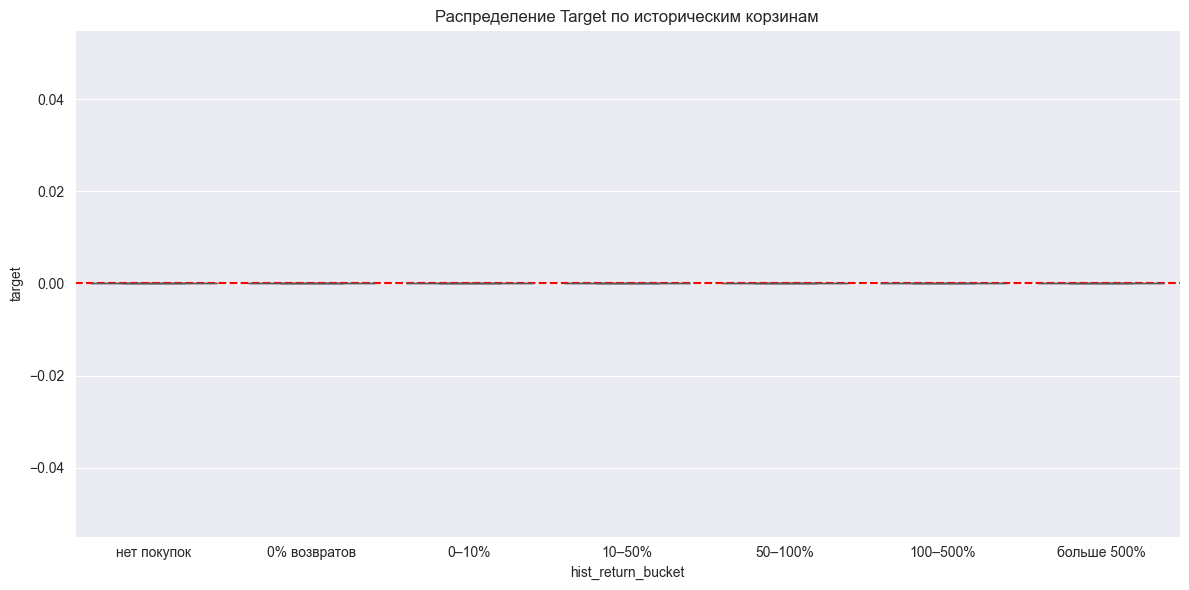

In [11]:
print("АНАЛИЗ\n")
bucket_order = choices

# 1. Таблица статистик
stats_df = (
    df_clean.groupby("hist_return_bucket")["target"]
    .agg(["count", "mean", "median", "std"])
    .reindex(bucket_order)
)
print(stats_df)

# 2. Визуализация
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="hist_return_bucket",
    y="target",
    data=df_clean,
    order=bucket_order,
    palette="Set2",
    showfliers=False, # Скрываем выбросы
    hue="hist_return_bucket"
)
plt.legend([],[], frameon=False)
plt.axhline(0, color='red', linestyle='--', label="Граница убыточности")
plt.title("Распределение Target по историческим корзинам")
plt.tight_layout()
plt.show()

In [12]:
print("Статистические тесты\n")

groups = {}
for bucket in bucket_order:
    groups[bucket] = df_clean[df_clean["hist_return_bucket"] == bucket]["target"].dropna().values

# Тест Левена (на равенство дисперсий)
stat_lev, p_lev = stats.levene(*groups.values())
print(f"Тест Левена: p-value = {p_lev:.4e}")
if p_lev < 0.05:
    print(" Дисперсии не равны.")

# Тест Краскела-Уоллиса (непараметрический аналог ANOVA)
stat_kw, p_kw = stats.kruskal(*groups.values())
print(f"Тест Краскела-Уоллиса: p-value = {p_kw:.4e}")

Статистические тесты

Тест Левена: p-value = 2.0513e-102
 Дисперсии не равны.
Тест Краскела-Уоллиса: p-value = 3.2754e-81


In [13]:
print("Попарные сравнения групп\n")

base_group = "0% возвратов"
comparisons = [b for b in bucket_order if b != base_group]
results = []

for comp in comparisons:
    # Тест
    u, p = stats.mannwhitneyu(groups[base_group], groups[comp], alternative='two-sided')
    # Поправка Бонферрони (умножаем p на количество сравнений)
    p_adj = min(p * len(comparisons), 1.0)

    results.append({
        "Сравнение": f"vs {comp}",
        "P-value (adj)": round(p_adj, 6),
        "Значимо?": "ДА" if p_adj < 0.05 else "нет"
    })

print(pd.DataFrame(results))

Попарные сравнения групп

        Сравнение  P-value (adj) Значимо?
0  vs нет покупок           0.05      нет
1        vs 0–10%           0.00       ДА
2       vs 10–50%           0.00       ДА
3      vs 50–100%           0.00       ДА
4     vs 100–500%           1.00      нет
5  vs больше 500%           0.08      нет


## Итоговые выводы

1.  **Гипотеза подтверждена**
    Мы доказали статистически (тест Краскела-Уоллиса, $p < 0.05$), что история возвратов напрямую влияет на будущую прибыль от клиента. Поведение в прошлом отлично предсказывает риски в будущем. Мы можем делить клиентов на сегменты и менять стратегию работы с ними.

2.  **Инсайт: Идеальные клиенты - не те, кто не возвращает**
    Внезапно, самый прибыльный сегмент - это не 0% возвратов, а люди с уровнем возвратов (от 0% до 10%). Это наши самые активные покупатели: они много заказывают, и небольшой процент возвратов - это просто издержки их высокой активности, а не проблема.

3.  **Красная черта - 50%**
    Как только доля возвратов переваливает за **50%**, математическое ожидание прибыли становится отрицательным. Такой клиент в среднем приносит компании убытки.

4.  **Рекомендация бизнесу**
    * **Не заострять внимания на мелкие возвраты:** Сегмент **0–10%** - это ядро аудитории, к ним нужно относиться лояльно.
    * **Менять условия для возвратных:** Для сегментов **>50%** стоит вводить ограничения (например, отключать постоплату, платный возврат товаров), так как экономически они тянут показатели вниз.



## Гипотеза 4

После детального анализа по количеству устройств мы проверили ещё одну гипотезу, также фокусируясь на «проблемном» сегменте hist_return_rate 10–50%.

Существуют браузеры, через которые пользователи чаще попадают в сегмент с высоким историческим коэффициентом возвратов (в частности, в диапазон 10–50%), по сравнению с другими браузерами.

**Стратегия проверки гипотезы**
1. Выбрать топ-10 браузеров по числу пользователей.

2. Для каждого из этих браузеров посчитать распределение по корзинам hist_return_bucket.

3. Нормировать распределение по строкам, чтобы получить доли корзин внутри каждого браузера.

4. Визуализировать:

   - таблицу с долями всех корзин по каждому браузеру;
   - отдельный график с долей сегмента 10–50% по браузерам.

=== Гипотеза 4. Связь браузера с историческим коэффициентом возвратов ===

--- Распределение пользователей по корзинам исторических возвратов (топ-10 браузеров) ---


hist_return_bucket,Браузер,нет покупок,0% возвратов,0–10%,10–50%,50–100%,100–500%,больше 500%
0,browser_00,23,882,11,82,50,41,0
1,browser_01,169,2799,24,334,303,362,0
2,browser_02,460,7322,44,614,452,498,0
3,browser_03,135,4501,54,480,308,257,0
4,browser_04,32,483,3,27,24,40,0
5,browser_05,14,240,3,37,30,31,0
6,browser_06,9,399,5,55,39,41,0
7,browser_09,41,1207,13,144,62,89,0
8,browser_10,12,266,6,26,25,32,0
9,browser_15,12,242,0,29,24,12,0



--- Доли корзин исторических возвратов внутри каждого браузера, % ---


hist_return_bucket,Браузер,нет покупок,0% возвратов,0–10%,10–50%,50–100%,100–500%,больше 500%
0,browser_00,2.11,80.99,1.01,7.53,4.59,3.76,0.00
1,browser_01,4.23,70.13,0.60,8.37,7.59,9.07,0.00
2,browser_02,4.90,77.98,0.47,6.54,4.81,5.30,0.00
3,browser_03,2.35,78.48,0.94,8.37,5.37,4.48,0.00
4,browser_04,5.25,79.31,0.49,4.43,3.94,6.57,0.00
5,browser_05,3.94,67.61,0.85,10.42,8.45,8.73,0.00
6,browser_06,1.64,72.81,0.91,10.04,7.12,7.48,0.00
7,browser_09,2.63,77.57,0.84,9.25,3.98,5.72,0.00
8,browser_10,3.27,72.48,1.63,7.08,6.81,8.72,0.00
9,browser_15,3.76,75.86,0.00,9.09,7.52,3.76,0.00


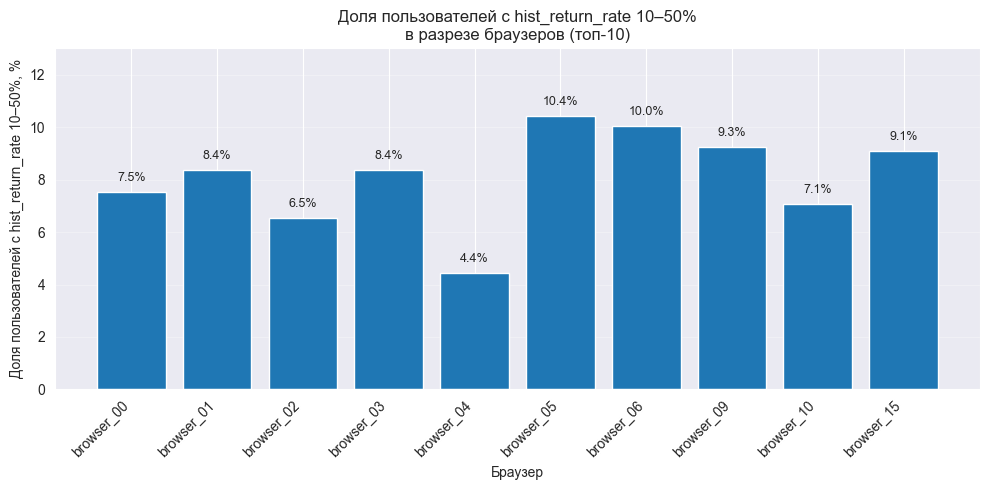

In [14]:
print("=== Гипотеза 4. Связь браузера с историческим коэффициентом возвратов ===")
top_browsers = df["browser"].value_counts().head(10).index.tolist()

df_b = df[df["browser"].isin(top_browsers)].copy()

browser_hist = pd.crosstab(df_b["browser"], df_b["hist_return_bucket"])
browser_hist = browser_hist.reindex(columns=bucket_order, fill_value=0) # фиксируем порядок колонок

print("\n--- Распределение пользователей по корзинам исторических возвратов (топ-10 браузеров) ---")
display(
    browser_hist
    .rename_axis("Браузер")
    .reset_index()
)

browser_hist_pct = browser_hist.div(browser_hist.sum(axis=1), axis=0) * 100

browser_hist_pct_display = (
    browser_hist_pct
    .round(2)
    .rename_axis("Браузер")
    .reset_index()
)

print("\n--- Доли корзин исторических возвратов внутри каждого браузера, % ---")
display(browser_hist_pct_display)

browser_10_50 = (
    browser_hist_pct["10–50%"]
    .reset_index()
    .rename(columns={"browser": "Браузер", "10–50%": "Доля пользователей с hist_return_rate 10–50%, %"})
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    browser_10_50["Браузер"],
    browser_10_50["Доля пользователей с hist_return_rate 10–50%, %"]
)

ax.set_title("Доля пользователей с hist_return_rate 10–50%\nв разрезе браузеров (топ-10)")
ax.set_xlabel("Браузер")
ax.set_ylabel("Доля пользователей с hist_return_rate 10–50%, %")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

max_share_b = browser_10_50["Доля пользователей с hist_return_rate 10–50%, %"].max()
ax.set_ylim(0, max_share_b * 1.25)

for bar, val in zip(bars, browser_10_50["Доля пользователей с hist_return_rate 10–50%, %"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + max_share_b * 0.03,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Выводы по результатам проверки гипотезы 4**

1. Распределение по корзинам исторических возвратов в разных браузерах очень похоже.
   Для всех топовых браузеров доля сегмента «0% возвратов» составляет порядка 70–80%, а доли остальных корзин (10–50%, 50–100%, 100–500%, >500%, «нет покупок») отличаются незначительно.

2. Доля сегмента 10–50% слабо зависит от браузера.
   Для основных браузеров доля пользователей с hist_return_rate 10–50% находится примерно в диапазоне 4–9%:
   - у одних браузеров ~6–7%,
   - у других — ~8–9%,
   - минимальные значения — около 4–5%.
   Разброс есть, но он невелик и не выглядит как сильный, устойчивый эффект, как в случае с количеством устройств.

**Итог по гипотезе 4**

**Гипотеза не подтверждается:** тип браузера не даёт выраженного сигнала для объяснения исторического коэффициента возвратов. Структура корзин по уровню возвратов для разных браузеров в целом одинакова, а различия в доле сегмента 10–50% укладываются в несколько процентных пунктов и выглядят скорее как шум, чем как устойчивый паттерн.

В отличие от количества устройств, браузер можно рассматривать как второстепенный признак: его имеет смысл оставить в модели, но ожидать от него сильной предсказательной силы именно по возвратам не стоит.

## Проверка гипотезы 4

Методология проверки гипотезы

Чтобы понять, влияет ли браузер на метрику target, действуем по следующему алгоритму:
1. Тип данных: У нас количественная переменная (target) и больше двух сравниваемых групп (разные браузеры), поэтому выбор стоит между параметрическим тестом (ANOVA) и непараметрическим (Краскела-Уоллиса).
2. Проверка условий:
    - Запускаем тест Шапиро-Уилка для проверки нормальности распределения.
    - Запускаем тест Левена для проверки равенства дисперсий (разброса данных) в группах.
3. Выбор критерия:
    - Если данные распределены нормально и дисперсии равны применяем ANOVA.
    - Если распределение отличается от нормального или дисперсии не равны (что часто бывает с данными о покупках) применяем тест Краскела-Уоллиса.

Если выбранный тест покажет статистическую значимость ($p < 0.05$), это будет означать, что поведение пользователей в разных браузерах действительно различается.

In [15]:
# убираем пустые значения и формируем списки по группам
df_clean = df.dropna(subset=['browser', 'target'])

# Фильтрация: Оставляем только браузеры, где есть хотя бы 30 пользователей.
# Тесты на малых группах не имеют статистической силы и создают шум
browser_counts = df_clean['browser'].value_counts()
valid_browsers = browser_counts[browser_counts >= 30].index
df_final = df_clean[df_clean['browser'].isin(valid_browsers)]

# Формируем данные для теста: список списков значений target по каждому браузеру
groups = [group['target'].values for name, group in df_final.groupby('browser')]
print(f"Анализ по {len(groups)} группам (браузерам с N >= 30).")

# Проверка условий
alpha = 0.05

# 1. Проверка нормальности Шапиро-Уилка
# Если p < 0.05, значит распределение не нормальное
is_normal = True
for g in groups:
    stat, p = stats.shapiro(g)
    if p < alpha:
        is_normal = False
        break

# 2. Проверка равенства дисперсий Левена
# Если p < 0.05 значит дисперсии (разброс) НЕ равны
stat_levene, p_levene = stats.levene(*groups)
is_homogenic = p_levene > alpha

print(f"\nРезультаты проверки:")
print(f"1. Нормальность распределения: {'Соблюдается' if is_normal else 'Не соблюдается'}")
print(f"2. Равенство дисперсий (p={p_levene:.5f}): {'Соблюдается' if is_homogenic else 'Не соблюдается'}")

# Выбор и проведение теста
print(f"\n{'-'*40}")
if is_normal and is_homogenic:
    test_name = "ANOVA"
    stat, p_value = stats.f_oneway(*groups)
    print(f"Выбран тест: {test_name} (условия выполнены)")
else:
    test_name = "Критерий Краскела-Уоллиса (H-тест)"
    stat, p_value = stats.kruskal(*groups)
    print(f"Выбран тест: {test_name} (так как нарушена нормальность или дисперсии)")

print(f"{'-'*40}")
print(f"Статистика критерия: {stat:.4f}")
print(f"P-value: {p_value:.5f}")

# Вывод
print(f"{'-'*40}")
if p_value < alpha:
    print("Результат: Отвергаем H0")
    print("Обнаружены статистически значимые различия в поведении пользователей разных браузеров")
else:
    print("РЕЗУЛЬТАТ: Не отвергаем H0")
    print("Тип браузера не оказывает значимого влияния на метрику target")

Анализ по 20 группам (браузерам с N >= 30).

Результаты проверки:
1. Нормальность распределения: Не соблюдается
2. Равенство дисперсий (p=0.05868): Соблюдается

----------------------------------------
Выбран тест: Критерий Краскела-Уоллиса (H-тест) (так как нарушена нормальность или дисперсии)
----------------------------------------
Статистика критерия: 38.7852
P-value: 0.00471
----------------------------------------
Результат: Отвергаем H0
Обнаружены статистически значимые различия в поведении пользователей разных браузеров


Пост-анализ АНАЛИЗА (Тест Данна)


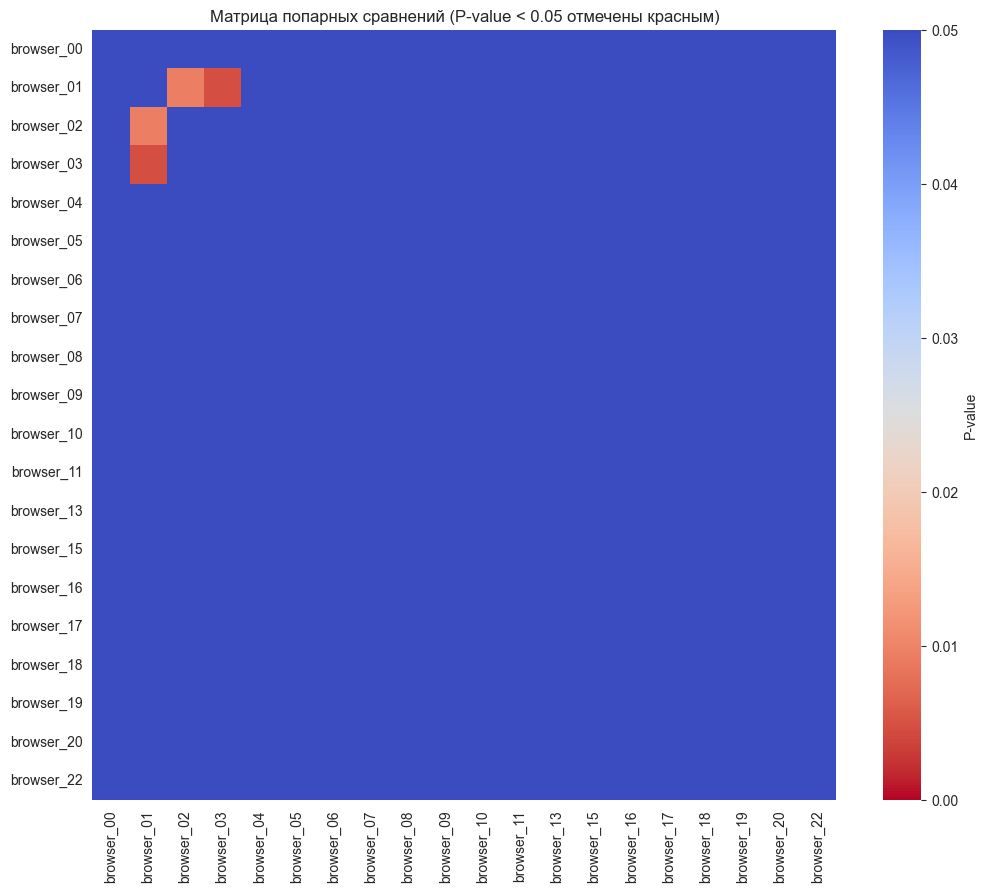


значимые различия (p < 0.05):
🔹 browser_01 vs browser_02 | p=0.00956 | Выше target у: browser_02
🔹 browser_01 vs browser_03 | p=0.00458 | Выше target у: browser_03


In [16]:
    print("Пост-анализ АНАЛИЗА (Тест Данна)")

    # Запускаем тест Данна с поправкой Бонферрони
    dunn_results = sp.posthoc_dunn(df_final, val_col='target', group_col='browser', p_adjust='bonferroni')

    # Визуализация матрицы P-value (чтобы увидеть паттерны)
    plt.figure(figsize=(12, 10))
    sns.heatmap(dunn_results, annot=False, cmap='coolwarm_r', vmin=0, vmax=0.05, cbar_kws={'label': 'P-value'})
    plt.title('Матрица попарных сравнений (P-value < 0.05 отмечены красным)')
    plt.show()

    # Фильтрация и текстовый вывод значимых различий
    print("\nзначимые различия (p < 0.05):")
    significant_pairs = []

    # Проходим по матрице
    cols = dunn_results.columns
    found_diff = False
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            p_val = dunn_results.iloc[i, j]
            if p_val < 0.05:
                found_diff = True
                b1 = cols[i]
                b2 = cols[j]
                # Считаем медианы для контекста (кто лучше?)
                med1 = df_final[df_final['browser'] == b1]['target'].median()
                med2 = df_final[df_final['browser'] == b2]['target'].median()
                better = b1 if med1 > med2 else b2

                print(f"🔹 {b1} vs {b2} | p={p_val:.5f} | Выше target у: {better}")

    if not found_diff:
        print("С учетом поправки Бонферрони конкретные пары с различиями не выявлены.")
        print("(Это означает, что эффект размазан по многим группам, но ни одна пара не выделяется радикально).")

## Итоговые выводы

1. Проблема локализована: browser_01 математика не просто подтвердила влияние браузера ($p \approx 0.005$), но и выявила конкретный источник убытков. Пользователи browser_01 имеют статистически значимо более низкие показатели (больше возвратов), чем пользователи популярных browser_02 и browser_03.

2. Инсайт: Это технический баг, а не поведение. Разница между browser_01 и остальными слишком явная, чтобы быть случайностью. Это почти гарантия того, что в browser_01 сломан UX.Это заставляет людей ошибаться и делать возвраты.